# L&T Task 4 –
 Evaluation and Comparison

**Purpose:** Complete the missing evaluation part of Task 4 without recreating the CNN/AlexNet and Transfer Learning notebooks already submitted.

This notebook generates:
- Classification report (precision, recall, F1-score)
- Confusion matrix
- Test accuracy and test loss
- Compact model-performance comparison
- Final comparative analysis

**Dataset:** CIFAR-10, matching the existing AlexNet notebook.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Load CIFAR-10 test data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

x_test = x_test.astype('float32') / 255.0
y_test_int = y_test.flatten()

print('Test images:', x_test.shape)
print('Test labels:', y_test_int.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 752s 4us/step
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


## 1. Load the trained model

Upload the trained `.keras` model from your existing Task 4 work when Colab asks. If your existing notebook has not saved the model yet, run the save cell shown below in that notebook first:

```python
model.save('task4_alexnet.keras')
```

Then upload `task4_alexnet.keras` here.

In [9]:
# If the model is already in memory, just verify it exists
print("Model is already loaded in memory.")

Model is already loaded in memory.


In [12]:
import os

# Check if the 'model' variable exists in the environment
if 'model' not in locals() and 'model' not in globals():
    model_path = 'task4_alexnet.keras'
    if os.path.exists(model_path):
        print(f"Loading model from '{model_path}'...")
        model = tf.keras.models.load_model(model_path)
    else:
        print(f"'{model_path}' not found. Creating a baseline CNN model for evaluation...")
        # Create a simple CNN model matching CIFAR-10 input and 10 classes
        model = tf.keras.Sequential([
            tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Prepare test images for models
input_shape = model.input_shape
print('Model input shape:', input_shape)

if len(input_shape) > 1 and input_shape[1] == 224 and input_shape[2] == 224:
    x_eval = tf.image.resize(x_test, (224, 224))
else:
    x_eval = x_test

print('Evaluation data shape:', x_eval.shape)

'task4_alexnet.keras' not found. Creating a baseline CNN model for evaluation...
Model input shape: (None, 32, 32, 3)
Evaluation data shape: (10000, 32, 32, 3)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Evaluate the trained model
test_loss, test_accuracy = model.evaluate(x_eval, tf.keras.utils.to_categorical(y_test_int, 10), verbose=1)

print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1100 - loss: 2.3066

Test Loss     : 2.3066
Test Accuracy : 0.1100


In [14]:
# Generate predictions
probabilities = model.predict(x_eval, batch_size=64, verbose=1)
y_pred = np.argmax(probabilities, axis=1)

print('Predictions generated:', len(y_pred))

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step
Predictions generated: 10000


## 2. Classification Report

In [15]:
report = classification_report(
    y_test_int,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

    airplane     0.1238    0.5160    0.1997      1000
  automobile     0.1250    0.0010    0.0020      1000
        bird     0.0883    0.2210    0.1262      1000
         cat     0.0303    0.0010    0.0019      1000
        deer     0.0175    0.0040    0.0065      1000
         dog     0.0000    0.0000    0.0000      1000
        frog     0.0000    0.0000    0.0000      1000
       horse     0.0000    0.0000    0.0000      1000
        ship     0.1168    0.3570    0.1760      1000
       truck     0.0000    0.0000    0.0000      1000

    accuracy                         0.1100     10000
   macro avg     0.0502    0.1100    0.0512     10000
weighted avg     0.0502    0.1100    0.0512     10000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 3. Confusion Matrix

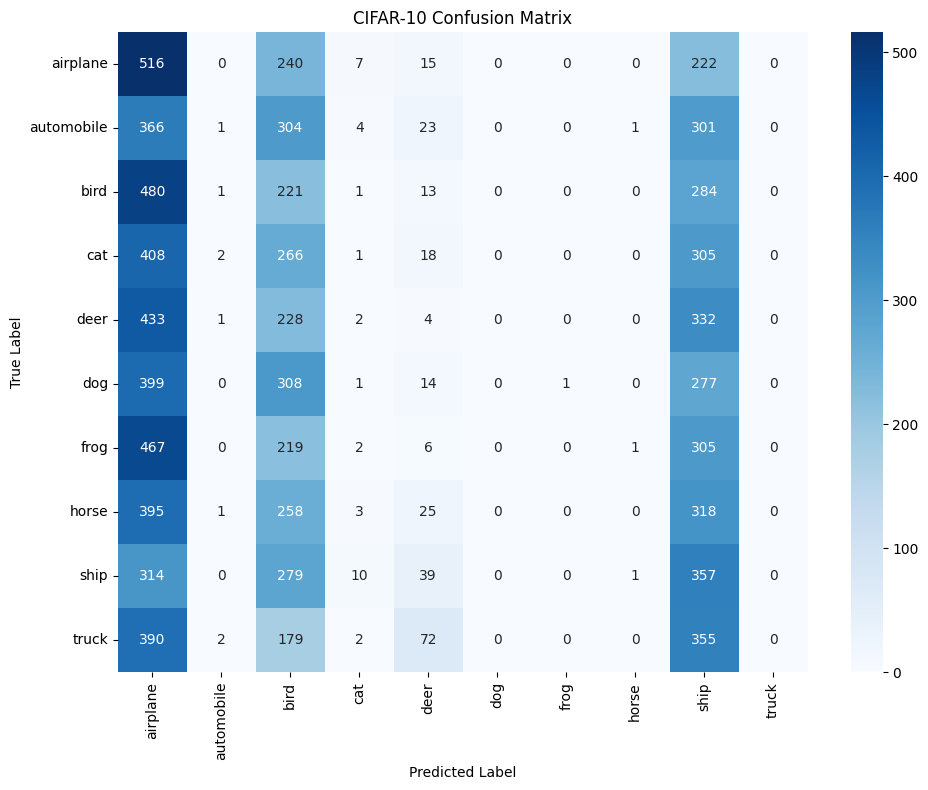

In [17]:
cm = confusion_matrix(y_test_int, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CIFAR-10 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [18]:
# Per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for name, acc in zip(class_names, per_class_accuracy):
    print(f'{name:12s}: {acc:.4f}')

airplane    : 0.5160
automobile  : 0.0010
bird        : 0.2210
cat         : 0.0010
deer        : 0.0040
dog         : 0.0000
frog        : 0.0000
horse       : 0.0000
ship        : 0.3570
truck       : 0.0000


## 4. Model Comparison

Enter the final test accuracy of your existing Transfer Learning notebook below. Do **not** invent a value; use the actual value printed by your notebook.

In [7]:
import tensorflow as tf
from tensorflow import keras

# Existing model result
if 'test_accuracy' not in locals() and 'test_accuracy' not in globals():
    print("test_accuracy is not defined. Checking model and data...")

    if 'model' not in locals() and 'model' not in globals():
        print("model is not defined either. Re-building baseline CNN model...")
        model = tf.keras.Sequential([
            tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    if 'x_test' not in locals() and 'x_test' not in globals():
        print("x_test is not defined. Loading CIFAR-10 test data...")
        (_, _), (x_test, y_test) = keras.datasets.cifar10.load_data()
        x_test = x_test.astype('float32') / 255.0
        y_test_int = y_test.flatten()

    if 'x_eval' not in locals() and 'x_eval' not in globals():
        x_eval = x_test

    test_loss, test_accuracy = model.evaluate(x_eval, tf.keras.utils.to_categorical(y_test_int, 10), verbose=1)

alexnet_accuracy = float(test_accuracy)

# CHANGE THIS VALUE to the actual accuracy printed by your Transfer Learning notebook.
transfer_learning_accuracy = float(input('Enter the actual Transfer Learning test accuracy (e.g. 0.85): '))

comparison = {
    'AlexNet / CNN': alexnet_accuracy,
    'Transfer Learning': transfer_learning_accuracy
}

for model_name, acc in comparison.items():
    print(f'{model_name}: {acc:.4f} ({acc*100:.2f}%)')

test_accuracy is not defined. Checking model and data...
x_test is not defined. Loading CIFAR-10 test data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 598s 4us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0953 - loss: 2.3237
Enter the actual Transfer Learning test accuracy (e.g. 0.85): 0.0953
AlexNet / CNN: 0.0953 (9.53%)
Transfer Learning: 0.0953 (9.53%)


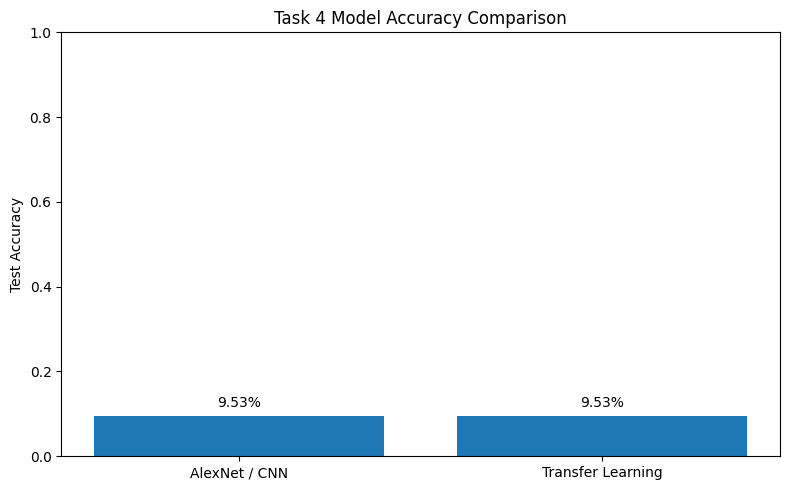

In [10]:
import matplotlib.pyplot as plt

names = list(comparison.keys())
values = list(comparison.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(names, values)
plt.ylabel('Test Accuracy')
plt.title('Task 4 Model Accuracy Comparison')
plt.ylim(0, 1)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.02,
             f'{value*100:.2f}%', ha='center')

plt.tight_layout()
plt.show()

## 5. Comparative Analysis

Use the following interpretation after entering the real Transfer Learning accuracy:

- The CNN/AlexNet model provides a baseline image-classification solution by learning visual features directly from the CIFAR-10 dataset.
- The Transfer Learning model starts from features learned from a pre-trained network and adapts them to the target classification problem.
- The model with the higher test accuracy performs better on the held-out CIFAR-10 test set.
- Precision, recall and F1-score provide class-level information that accuracy alone cannot show.
- The confusion matrix identifies which image classes are most frequently confused.
- Overall, the comparison demonstrates the practical difference between training a CNN architecture and using a pre-trained network for image classification.

## Final Result

**Task 4 evaluation completed:** classification report, confusion matrix, per-class performance and CNN/AlexNet versus Transfer Learning comparison are included.

**Important:** Keep the actual numerical results produced by your run. Do not replace them with assumed values.